# **Autoencoders for Dimensionality Reduction**
### MNIST Dataset  

### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.manifold import TSNE

### Load Data

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.
X_test = X_test.astype("float32") / 255.

X_train = np.reshape(X_train, (-1, 28, 28, 1))
X_test = np.reshape(X_test, (-1, 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Sample Images

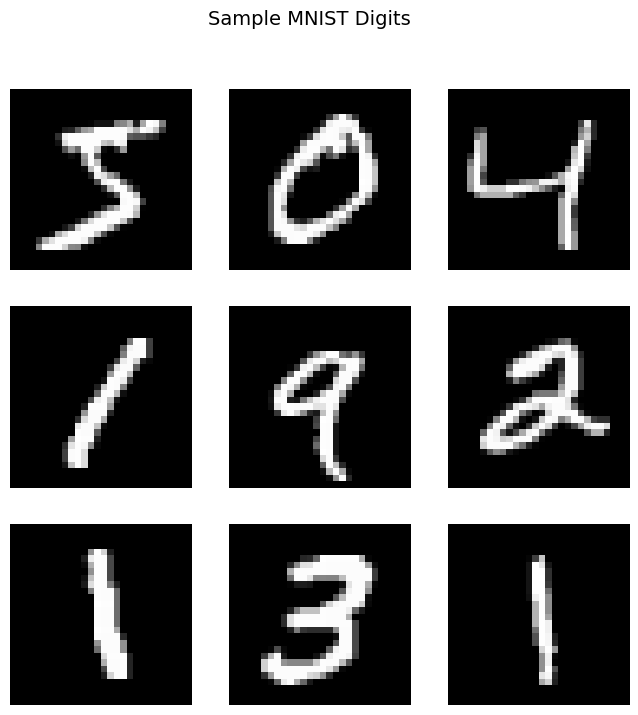

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Sample MNIST Digits", fontsize=14)
plt.savefig("sample_mnist_digits.png")
plt.show()

### Build Encoder + Decoder

In [ ]:
input_img = layers.Input(shape=(28,28,1))

# Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

encoded = layers.Conv2D(8, 3, activation='relu', padding='same')(x)

# Decoder
x = layers.Conv2D(8, 3, activation='relu', padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)

decoded = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### Train Model

In [ ]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=256,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 205s 875ms/step - loss: 0.1129 - val_loss: 0.0910
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 166s 707ms/step - loss: 0.0875 - val_loss: 0.0836
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 148s 629ms/step - loss: 0.0818 - val_loss: 0.0790
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 147s 628ms/step - loss: 0.0788 - val_loss: 0.0772
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 147s 625ms/step - loss: 0.0769 - val_loss: 0.0753


### Loss Curve

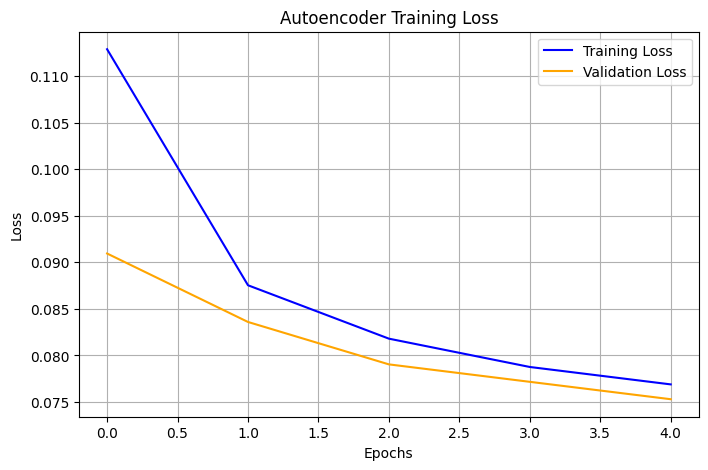

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')

plt.title("Autoencoder Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("autoencoder_training_loss.png")
plt.show()

### Reconstruction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


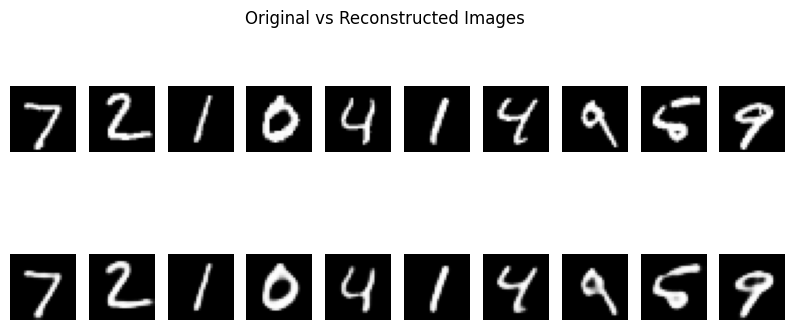

In [ ]:
decoded_imgs = autoencoder.predict(X_test[:10])

plt.figure(figsize=(10,4))

for i in range(10):
    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images")
plt.savefig("reconstructed_images.png")
plt.show()

### Latent Space (t-SNE)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


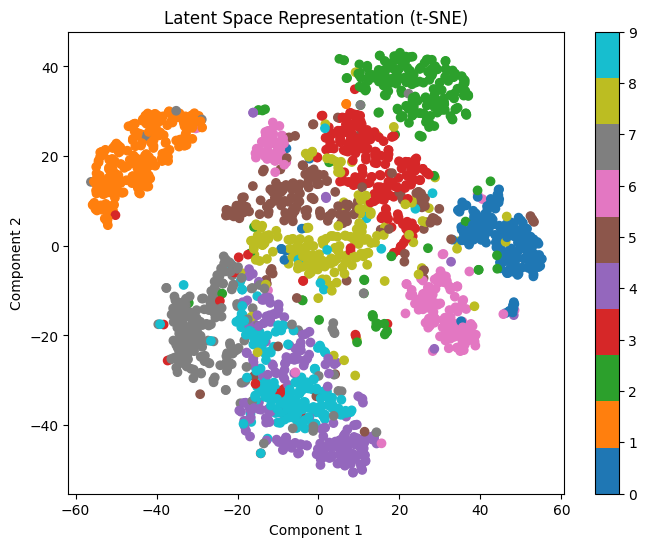

In [ ]:
encoder = Model(input_img, encoded)
encoded_imgs = encoder.predict(X_test)
encoded_flat = encoded_imgs.reshape(len(encoded_imgs), -1)

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(encoded_flat[:2000])

plt.figure(figsize=(8,6))
scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=y_test[:2000], cmap='tab10')

plt.colorbar(scatter)
plt.title("Latent Space Representation (t-SNE)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.savefig("latent_space_representation.png")
plt.show()

### Train Denoising Model

In [ ]:
noise_factor = 0.3

X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(size=X_test.shape)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

denoise_model = Model(input_img, decoded)
denoise_model.compile(optimizer='adam', loss='binary_crossentropy')

denoise_model.fit(
    X_train_noisy, X_train,
    epochs=5,
    batch_size=256,
    validation_data=(X_test_noisy, X_test),
    verbose=1
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 162s 676ms/step - loss: 0.0954 - val_loss: 0.0892
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 664ms/step - loss: 0.0893 - val_loss: 0.0879
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 195s 633ms/step - loss: 0.0882 - val_loss: 0.0869
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 205s 643ms/step - loss: 0.0873 - val_loss: 0.0862
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 198s 628ms/step - loss: 0.0867 - val_loss: 0.0858


### Denoising Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


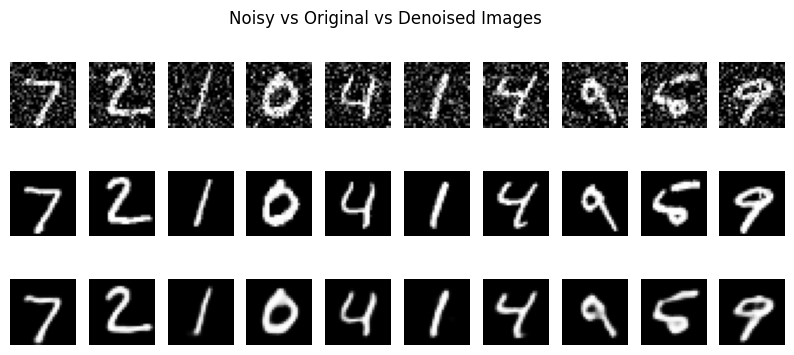

In [ ]:
denoised_imgs = denoise_model.predict(X_test_noisy[:10])

plt.figure(figsize=(10,4))

for i in range(10):
    # Noisy
    plt.subplot(3,10,i+1)
    plt.imshow(X_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Clean
    plt.subplot(3,10,i+11)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Denoised
    plt.subplot(3,10,i+21)
    plt.imshow(denoised_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Noisy vs Original vs Denoised Images")
plt.savefig("denoised_images.png")
plt.show()

### Error Distribution

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


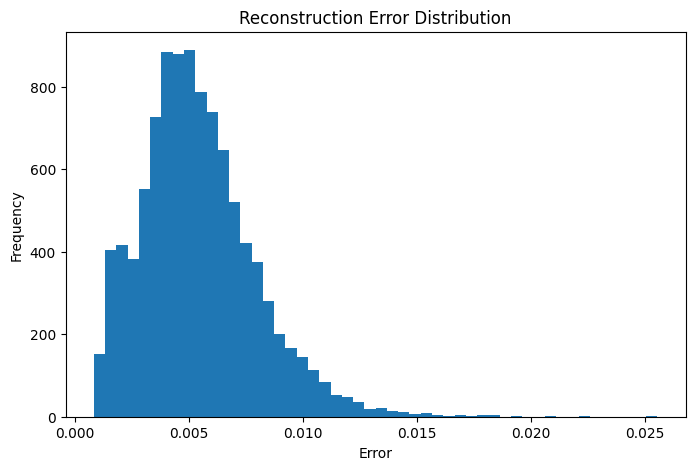

In [ ]:
reconstructions = autoencoder.predict(X_test)
errors = np.mean((X_test - reconstructions)**2, axis=(1,2,3))

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.savefig("reconstruction_error_distribution.png")
plt.show()